In [1]:
import numpy as np
import scanpy as sc
import scvelo as scv
from pathlib import Path

sc.set_figure_params(dpi=120, frameon=False)
scv.settings.verbosity = 3
scv.settings.presenter_view = True


In [2]:
adata = sc.read_h5ad("data/GSE280305_paths_AB.h5ad")
adata
print("obsm keys:", [k for k in ["X_umap_raw", "X_umap_scanorama", "X_scanorama"] if k in adata.obsm])
print("neighbors:", [k for k in ["nbrs_raw", "nbrs_scanorama"] if k in adata.uns])
print("timepoints:", adata.obs["timepoint"].value_counts().to_dict())


obsm keys: ['X_umap_raw', 'X_umap_scanorama', 'X_scanorama']
neighbors: ['nbrs_raw', 'nbrs_scanorama']
timepoints: {'D8': 13149, 'D21': 8329, 'D14': 5614, 'D11': 4513}


In [3]:
raw_paths = sorted(Path("/mnt/d/scgeo/data/GSE280305_h5ad").glob("GSM*_count.h5ad"))
raw_ads = [sc.read_h5ad(p) for p in raw_paths]

# Make var names unique (safe)
for a in raw_ads:
    a.var_names_make_unique()

# Intersect genes (safe)
common = set(raw_ads[0].var_names)
for a in raw_ads[1:]:
    common &= set(a.var_names)
common = sorted(common)

raw_ads = [a[:, common].copy() for a in raw_ads]

adata_raw = sc.concat(
    raw_ads,
    label="timepoint",
    keys=[a.obs["timepoint"].unique()[0] for a in raw_ads],
    join="inner",
    merge="same",
)
# Use raw counts
if "matrix" in adata_raw.layers:
    adata_raw.X = adata_raw.layers["matrix"]

print(adata_raw)
print("layers:", list(adata_raw.layers.keys()))


AnnData object with n_obs × n_vars = 31605 × 32285
    obs: 'timepoint', 'sample', 'gsm'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
layers: ['ambiguous', 'matrix', 'spliced', 'unspliced']


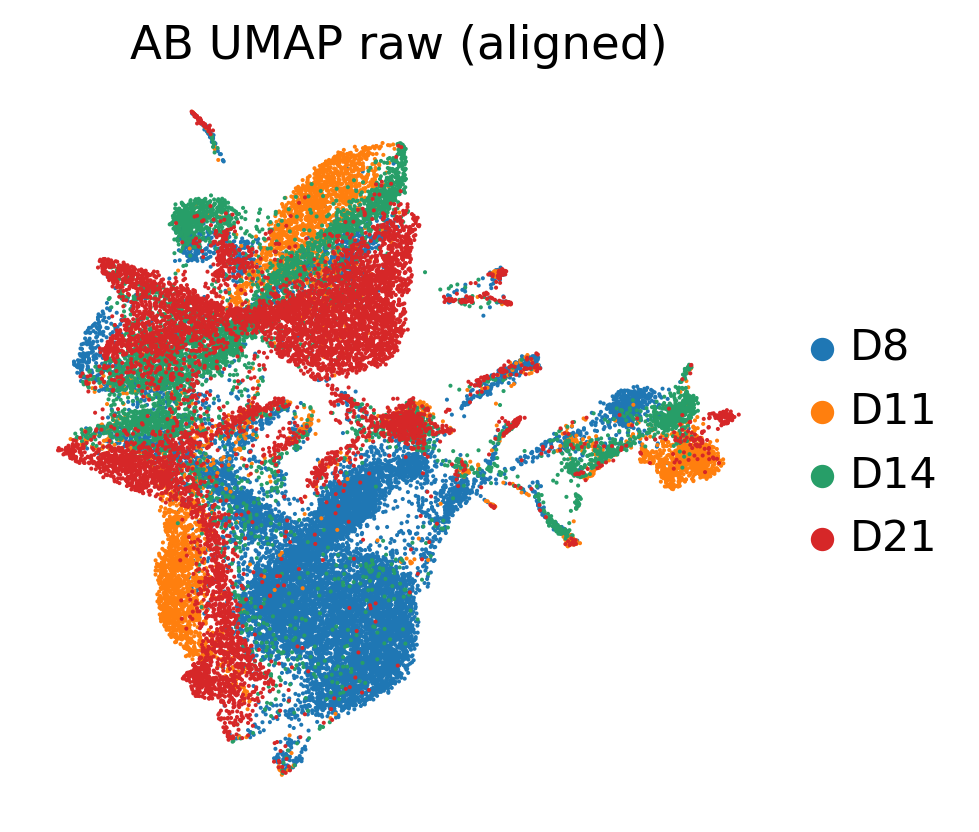

In [4]:
# Fast reorder only (no intersection)
# Safety check
assert adata.obs_names.is_unique and adata_raw.obs_names.is_unique

# If same set of cells, reorder to match adata (fast)
missing = adata.obs_names.difference(adata_raw.obs_names)
assert len(missing) == 0, f"Missing in adata_raw: {len(missing)}"

adata_raw = adata_raw[adata.obs_names]   # view-like; no .copy()

# Attach UMAPs (cheap)
adata_raw.obsm["X_umap_raw"] = adata.obsm["X_umap_raw"]
adata_raw.obsm["X_umap_scanorama"] = adata.obsm["X_umap_scanorama"]

# Optional: quick plot to ensure things look sane
sc.pl.embedding(adata, "X_umap_raw", color="timepoint", title="AB UMAP raw (aligned)", size=6)


In [5]:
# Use scVelo's filter_and_normalize; it log1p's internally
scv.pp.filter_and_normalize(adata_raw, min_shared_counts=20, n_top_genes=1500)

# PCA + neighbors explicitly (scanpy), smaller = less RAM
sc.pp.pca(adata_raw,use_highly_variable=True)
sc.pp.neighbors(adata_raw)

# Moments uses existing neighbors; don't pass n_pcs/n_neighbors
scv.pp.moments(adata_raw)

scv.tl.velocity(adata_raw, mode="stochastic")
scv.tl.velocity_graph(adata_raw)

Filtered out 21129 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1500 highly variable genes.


/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


Logarithmized X.


/tmp/ipykernel_1103/3776002110.py:9: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata_raw)
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


computing neighbors
    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities


/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:13) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/6 cores)


  0%|          | 0/31605 [00:00<?, ?cells/s]

/usr/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=1103) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:01:19) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:06) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_catego

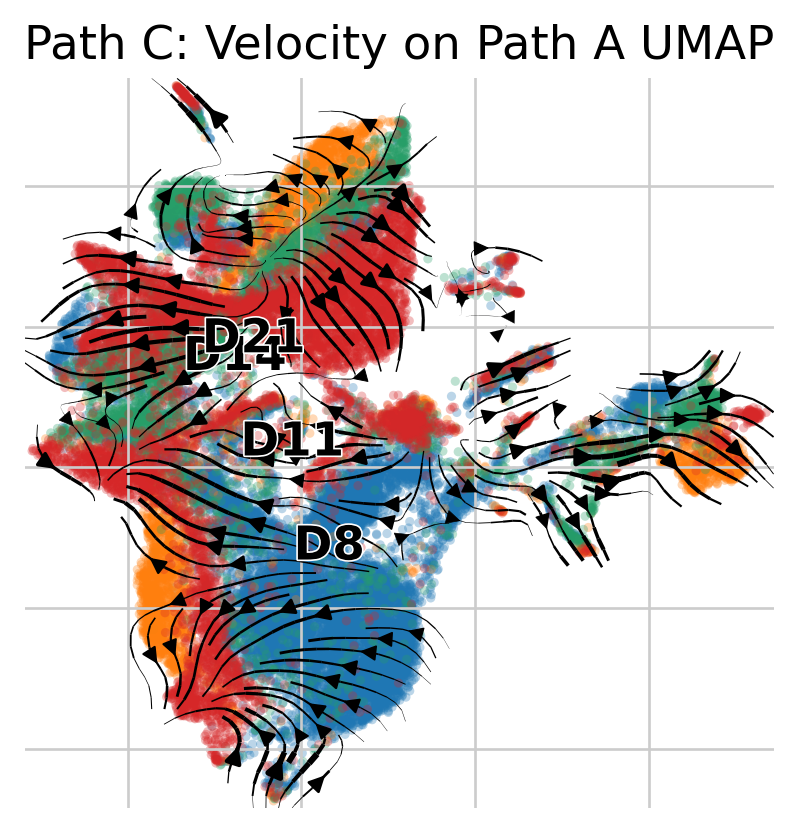

In [6]:
adata_raw.obsm["X_umap"] = adata_raw.obsm["X_umap_raw"]
scv.pl.velocity_embedding_stream(
    adata_raw, basis="umap", color="timepoint",
    title="Path C: Velocity on Path A UMAP"
)


/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/mnt/d/scgeo/.venv/lib/python3.12/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_catego

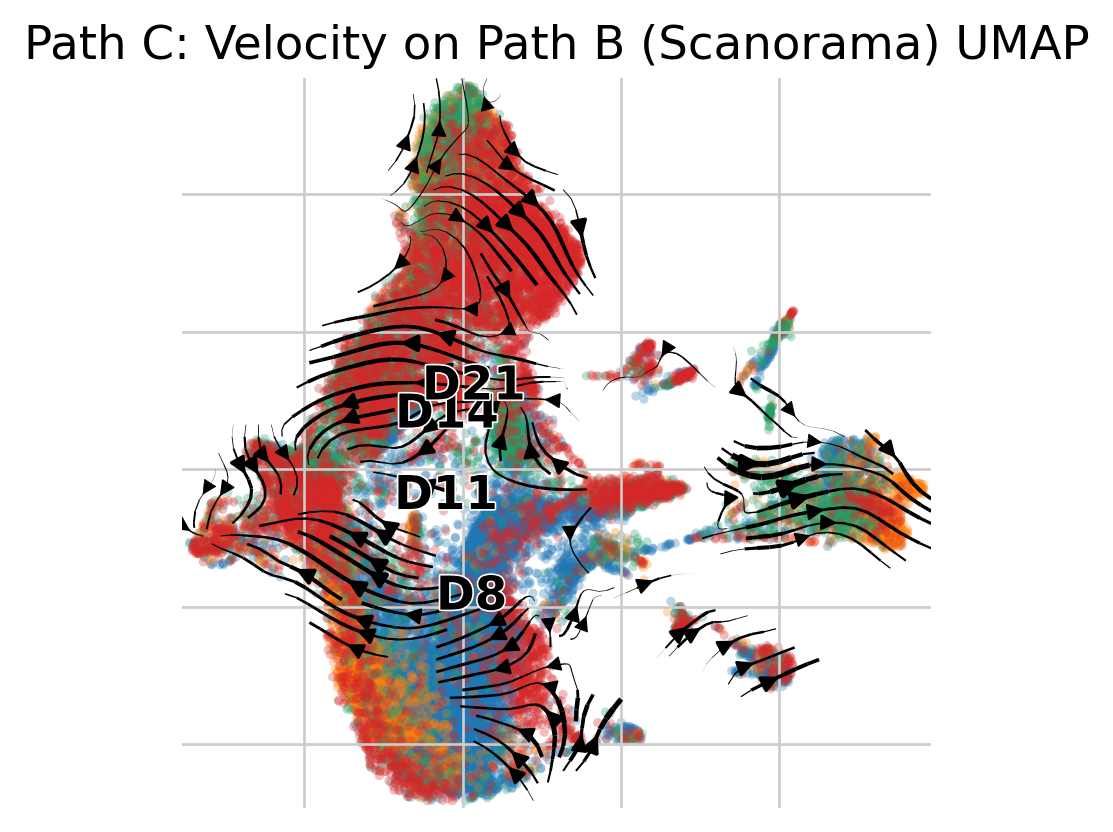

In [7]:
adata_raw.obsm["X_umap"] = adata_raw.obsm["X_umap_scanorama"]
scv.pl.velocity_embedding_stream(
    adata_raw, basis="umap", color="timepoint",
    title="Path C: Velocity on Path B (Scanorama) UMAP"
)


In [8]:
Path("data").mkdir(exist_ok=True)

adata_raw.write("data/GSE280305_velocity_full.h5ad")

